In [56]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

predictions = pd.read_csv(Path(r"C:\Users\skous\Super-League-odds-research\artifacts\scotland_model_evaluation\predictions.csv"))

predictions.head()

,model,match_id,season,match_date,home_team,away_team,result_3way,prob_H,prob_D,prob_A,predicted_result
0,frequency_baseline,mt_018408589,2022-23,2022-07-30,Heart of Midlothian,Ross County,H,0.407895,0.263158,0.328947,H
1,frequency_baseline,mt_405745252,2022-23,2022-07-30,Kilmarnock,Dundee United,D,0.407895,0.263158,0.328947,H
2,frequency_baseline,mt_587257974,2022-23,2022-07-30,St. Johnstone,Hibernian,A,0.407895,0.263158,0.328947,H
3,frequency_baseline,mt_621361016,2022-23,2022-07-30,Livingston,Rangers,A,0.407895,0.263158,0.328947,H
4,frequency_baseline,mt_259629190,2022-23,2022-07-31,St. Mirren,Motherwell,A,0.407895,0.263158,0.328947,H


In [57]:
predictions["model"].value_counts()

model
frequency_baseline         665
dixon_coles                665
dixon_coles_player_form    665
closing_market             665
player_form                665
market_plus_player_form    665
Name: count, dtype: int64

In [58]:
MODEL_NAME = "player_form"

model_predictions = (predictions.loc[predictions["model"] == MODEL_NAME].copy().reset_index(drop=True))

In [59]:
def trust_table(predictions, probability_column, result_code, bin_width=0.20):

    data = predictions[[probability_column, "result_3way"]].copy()
    data["outcome_happened"] = (data["result_3way"] == result_code).astype(int)

    bin_edges = np.arange(0, 1 + bin_width, bin_width)
    bin_edges[-1] = 1.000001

    data["probability_range"] = pd.cut(data[probability_column], bins=bin_edges, include_lowest=True, right=False)

    table = data.groupby("probability_range", observed=False).agg(matches=("outcome_happened", "size"), average_prediction=(probability_column, "mean"), actual_frequency=("outcome_happened", "mean")).reset_index()

    standard_error = np.sqrt(table["actual_frequency"] * (1 - table["actual_frequency"]) / table["matches"].replace(0, np.nan))

    table["lower_limit"] = (table["actual_frequency"] - 1.96 * standard_error).clip(lower=0)
    table["upper_limit"] = (table["actual_frequency"] + 1.96 * standard_error).clip(upper=1)

    return table

In [60]:
home_table = trust_table(model_predictions, "prob_H", "H")

home_table.style.format({
    "average_prediction": "{:.1%}",
    "actual_frequency": "{:.1%}",
    "lower_limit": "{:.1%}",
    "upper_limit": "{:.1%}",
})

,probability_range,matches,average_prediction,actual_frequency,lower_limit,upper_limit
0,"[0.0, 0.2)",89,12.3%,16.9%,9.1%,24.6%
1,"[0.2, 0.4)",208,30.9%,40.9%,34.2%,47.5%
2,"[0.4, 0.6)",232,48.7%,47.0%,40.6%,53.4%
3,"[0.6, 0.8)",107,68.8%,77.6%,69.7%,85.5%
4,"[0.8, 1.0)",29,84.5%,82.8%,69.0%,96.5%


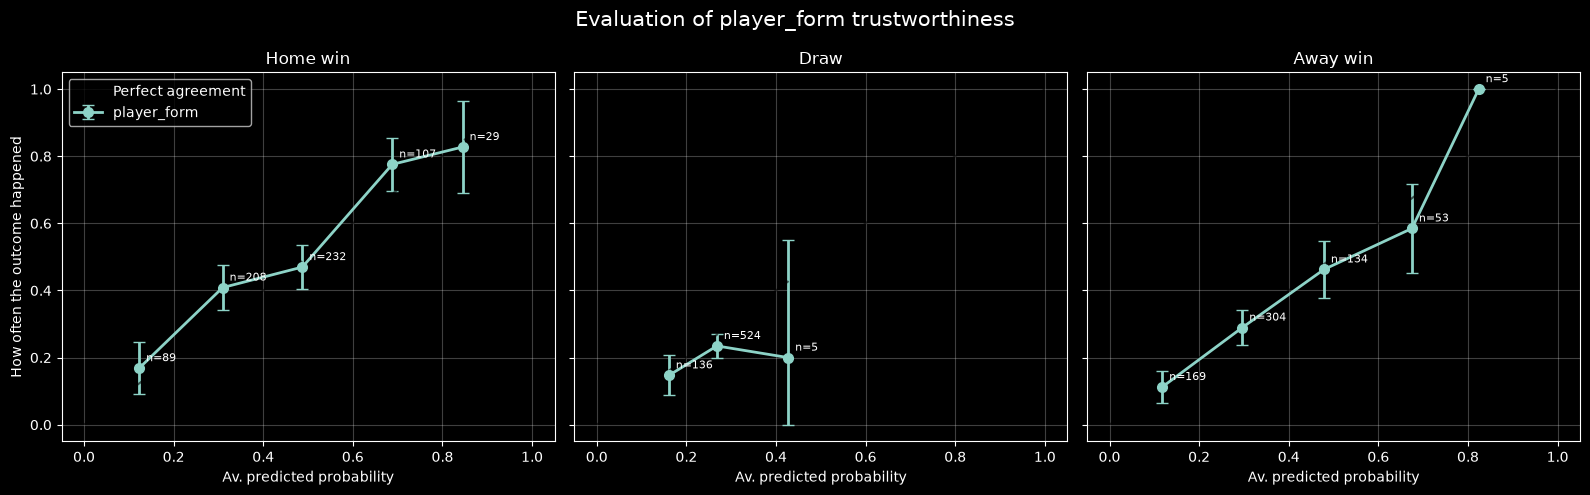

In [61]:
OUTCOMES = {
    "Home win": ("prob_H", "H"),
    "Draw": ("prob_D", "D"),
    "Away win": ("prob_A", "A"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
tables = {}

for axis, (label, (probability_column, result_code)) in zip(axes, OUTCOMES.items()):
    table = trust_table(model_predictions, probability_column, result_code)
    tables[label] = table
    plotted = table.dropna(subset=["average_prediction", "actual_frequency"])

    lower_error = plotted["actual_frequency"] - plotted["lower_limit"]
    upper_error = plotted["upper_limit"] - plotted["actual_frequency"]

    axis.errorbar(plotted["average_prediction"], plotted["actual_frequency"], yerr=[lower_error, upper_error], marker="o", markersize=7, linewidth=2, capsize=4, label=MODEL_NAME)
    axis.plot([0, 1], [0, 1], "--", color="black", alpha=0.6, label="Perfect agreement")

    for row in plotted.itertuples():
        axis.annotate(f"n={row.matches}", (row.average_prediction, row.actual_frequency), xytext=(5, 5), textcoords="offset points", fontsize=8)

    axis.set_title(label)
    axis.set_xlabel("Av. predicted probability")
    axis.grid(alpha=0.25)

axes[0].set_ylabel("How often the outcome happened")
axes[0].legend()

fig.suptitle(f"Evaluation of {MODEL_NAME} trustworthiness", fontsize=15)
plt.tight_layout()

output_path = Path("../visuals/model_trust") / f"{MODEL_NAME}_trustworthiness.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight")

plt.show()